In [1]:
!pip install -q optuna hdbscan umap-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd

import optuna
import umap
import hdbscan

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

c:\Users\rohit rawat\Desktop\iitr_internship\image_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
features = np.load(
    "../embeddings/dino_features.npy"
)

print(features.shape)

(51301, 384)


In [15]:
from pathlib import Path

image_dir = Path("../data/crop_alloy")

image_paths = sorted([
    str(p)
    for p in image_dir.rglob("*")
    if p.suffix.lower() in [
        ".jpg",
        ".jpeg",
        ".png",
        ".tif",
        ".tiff",
        ".bmp"
    ]
])

print("Images:", len(image_paths))

Images: 51301


In [5]:
def objective(trial):

    # PCA

    pca_dim = trial.suggest_int(
        "pca_dim",
        50,
        300
    )

    pca = PCA(
        n_components=pca_dim,
        random_state=42
    )

    X_pca = pca.fit_transform(
        features
    )

    # UMAP

    n_neighbors = trial.suggest_int(
        "n_neighbors",
        10,
        100
    )

    min_dist = trial.suggest_float(
        "min_dist",
        0.0,
        0.5
    )

    n_components = trial.suggest_int(
        "n_components",
        10,
        50
    )

    umap_model = umap.UMAP(

        n_neighbors=n_neighbors,

        min_dist=min_dist,

        n_components=n_components,

        metric="cosine",

        random_state=42
    )

    X_umap = umap_model.fit_transform(
        X_pca
    )

    # HDBSCAN

    min_cluster_size = trial.suggest_int(
        "min_cluster_size",
        50,
        500
    )

    min_samples = trial.suggest_int(
        "min_samples",
        5,
        100
    )

    clusterer = hdbscan.HDBSCAN(

        min_cluster_size=min_cluster_size,

        min_samples=min_samples,

        metric="euclidean",

        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(
        X_umap
    )

    # Ignore failed runs

    unique_clusters = len(
        set(labels)
    ) - (
        1 if -1 in labels else 0
    )

    if unique_clusters < 2:

        return -999

    # Remove noise

    mask = labels != -1

    if mask.sum() < 100:

        return -999

    try:

        sil = silhouette_score(
            X_umap[mask],
            labels[mask]
        )

    except:

        return -999

    noise_ratio = np.mean(
        labels == -1
    )

    # Penalize huge noise

    score = sil - 0.5 * noise_ratio

    return score

In [6]:
from tqdm.auto import tqdm
import optuna

N_TRIALS = 30

pbar = tqdm(total=N_TRIALS)

def callback(study, trial):

    pbar.update(1)

    pbar.set_postfix({
        "best_score": round(study.best_value, 4),
        "trial": trial.number + 1
    })

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    callbacks=[callback]
)

pbar.close()

  0%|          | 0/30 [00:00<?, ?it/s][I 2026-06-09 15:15:37,484] A new study created in memory with name: no-name-be46bea8-fe4a-4fa8-b4f8-cc2a5eefd744
c:\Users\rohit rawat\Desktop\iitr_internship\image_classification\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
[I 2026-06-09 15:18:05,843] Trial 0 finished with value: -0.047275196333836235 and parameters: {'pca_dim': 208, 'n_neighbors': 60, 'min_dist': 0.07582820493200465, 'n_components': 12, 'min_cluster_size': 373, 'min_samples': 29}. Best is trial 0 with value: -0.047275196333836235.
  3%|▎         | 1/30 [02:28<1:11:43, 148.40s/it, best_score=-0.0473, trial=1]c:\Users\rohit rawat\Desktop\iitr_internship\image_classification\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
[I 2026-06-09 15:20:13,377] Trial 1 finished with value: 0

In [7]:
print(
    "Best Score:",
    study.best_value
)

print(
    study.best_params
)

Best Score: 0.4892629085025165
{'pca_dim': 116, 'n_neighbors': 81, 'min_dist': 4.811343388737288e-05, 'n_components': 41, 'min_cluster_size': 181, 'min_samples': 43}


In [8]:
best = study.best_params

In [9]:
pca = PCA(
    n_components=best["pca_dim"],
    random_state=42
)

pca_features = pca.fit_transform(
    features
)

In [10]:
umap_model = umap.UMAP(

    n_neighbors=best["n_neighbors"],

    min_dist=best["min_dist"],

    n_components=best["n_components"],

    metric="cosine",

    random_state=42
)

umap_features = umap_model.fit_transform(
    pca_features
)

c:\Users\rohit rawat\Desktop\iitr_internship\image_classification\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [11]:
clusterer = hdbscan.HDBSCAN(

    min_cluster_size=best["min_cluster_size"],

    min_samples=best["min_samples"],

    metric="euclidean",

    cluster_selection_method="eom"
)

labels = clusterer.fit_predict(
    umap_features
)

In [12]:
labels

array([1, 1, 1, ..., 1, 2, 1], shape=(51301,))

In [13]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

mask = labels != -1

print(
    "Clusters:",
    len(set(labels))
)
print(
    "Noise:",
    np.sum(labels == -1)
)

print(
    "Silhouette:",
    silhouette_score(
        umap_features[mask],
        labels[mask]
    )
)

print(
    "Davies:",
    davies_bouldin_score(
        umap_features[mask],
        labels[mask]
    )
)

print(
    "Calinski:",
    calinski_harabasz_score(
        umap_features[mask],
        labels[mask]
    )
)

Clusters: 4
Noise: 459
Silhouette: 0.49373650550842285
Davies: 0.5137311002933623
Calinski: 128833.775092513


In [16]:
import pandas as pd

df = pd.DataFrame({
    "image_path": image_paths,
    "cluster": labels
})

print(df.head())

                               image_path  cluster
0  ..\data\crop_alloy\img10000_single.jpg        1
1  ..\data\crop_alloy\img10001_single.jpg        1
2       ..\data\crop_alloy\img10002_A.jpg        1
3       ..\data\crop_alloy\img10002_B.jpg        0
4       ..\data\crop_alloy\img10002_C.jpg        2


In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def show_cluster_random(cluster_id, n=30):

    paths = df[
        df["cluster"] == cluster_id
    ]["image_path"].tolist()

    if len(paths) == 0:
        print("Empty cluster")
        return

    paths = random.sample(
        paths,
        min(n, len(paths))
    )

    plt.figure(figsize=(15, 18))

    for i, path in enumerate(paths):

        try:

            img = Image.open(
                str(path)
            ).convert("RGB")

            plt.subplot(6, 5, i + 1)

            plt.imshow(img)

            plt.axis("off")

        except Exception as e:

            print("Error:", path)

    plt.suptitle(
        f"Cluster {cluster_id}",
        fontsize=20
    )

    plt.tight_layout()

    plt.show()


CLUSTER -1
Size: 459


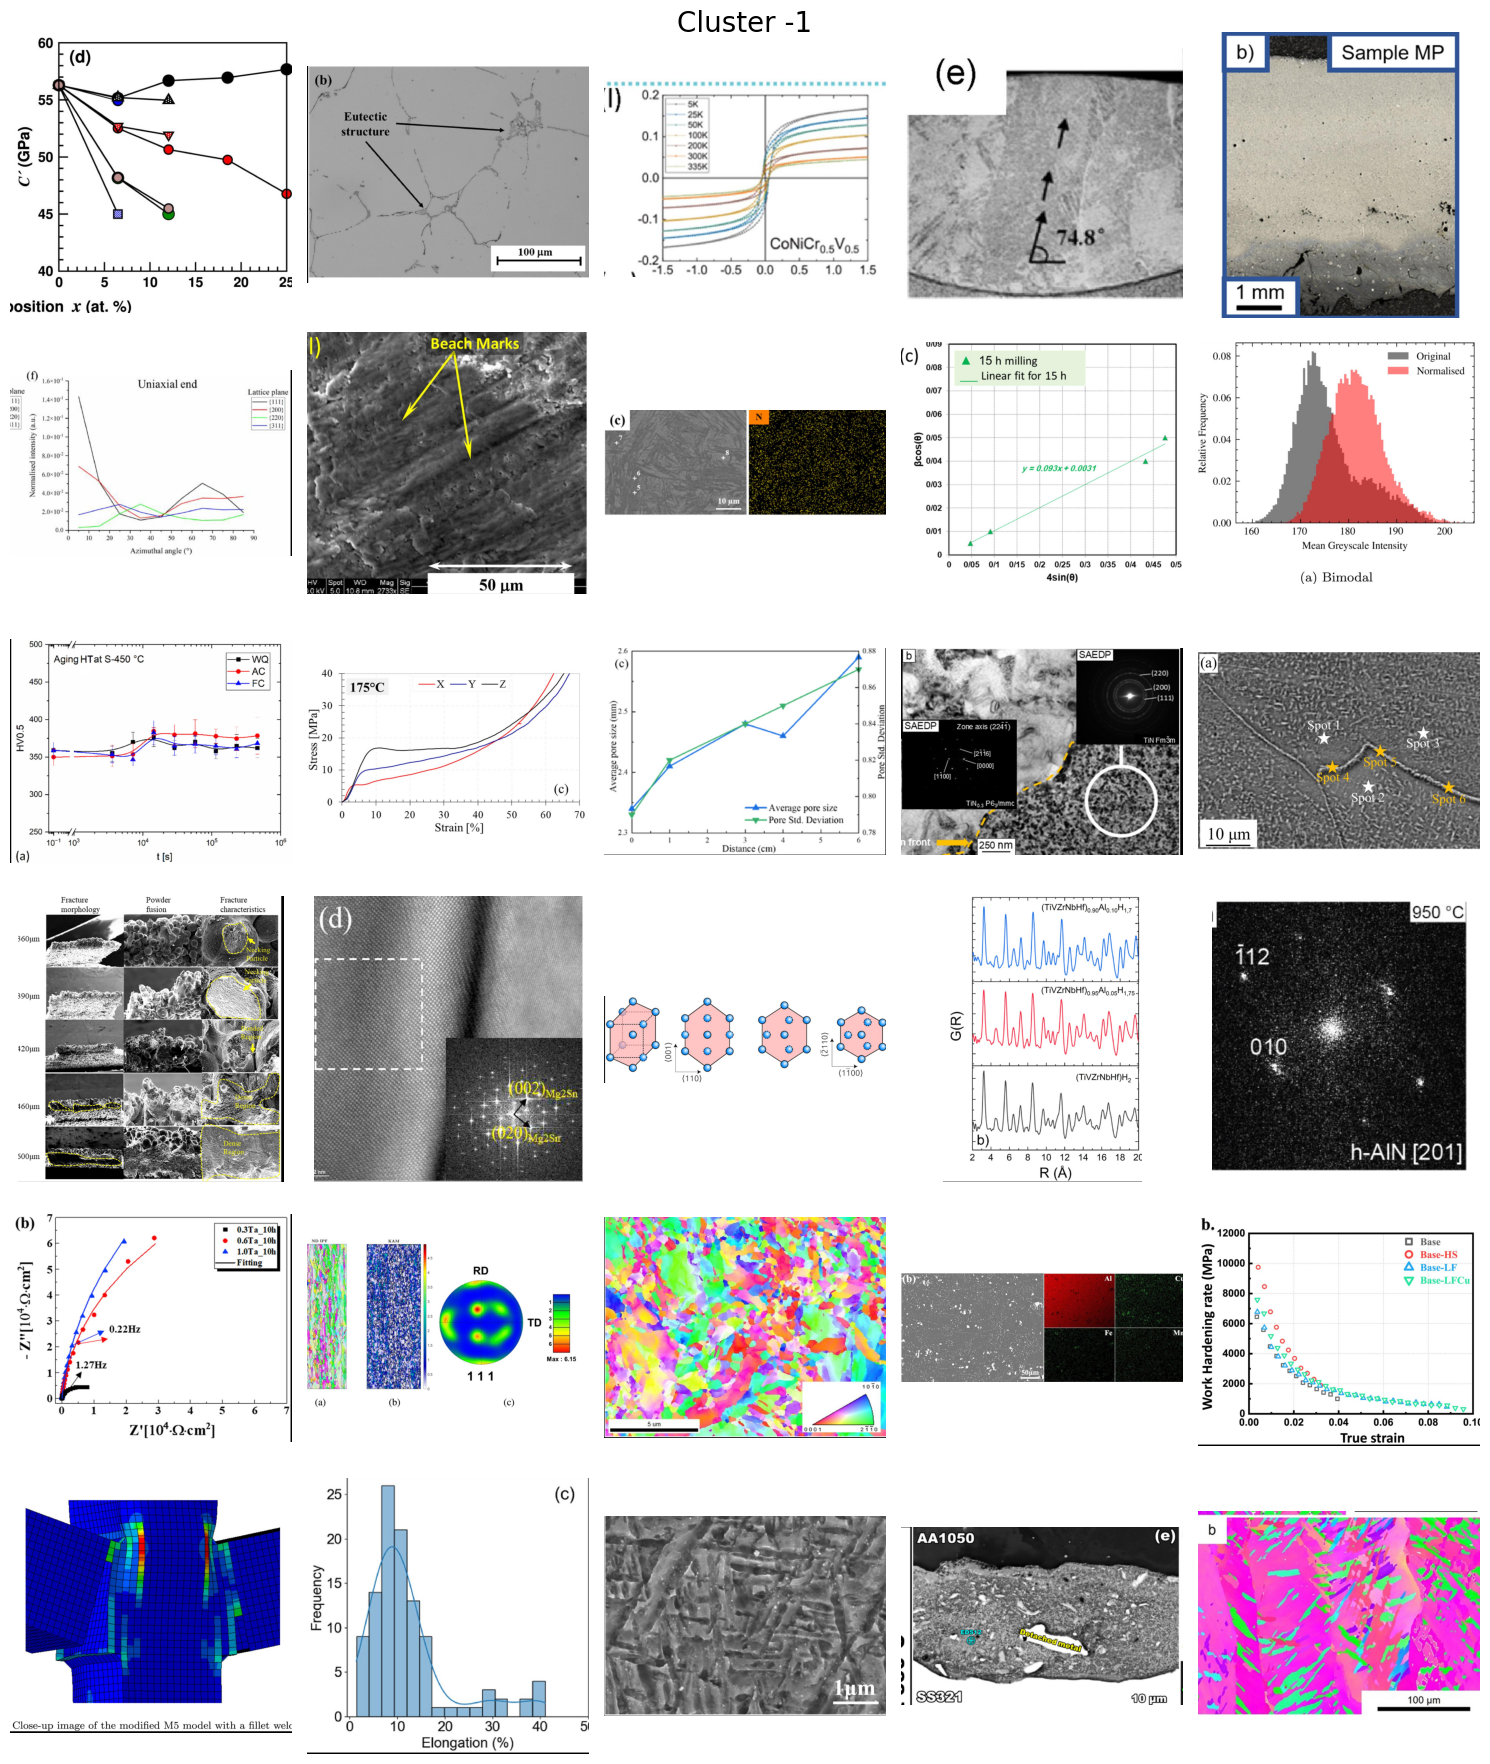


CLUSTER 0
Size: 690


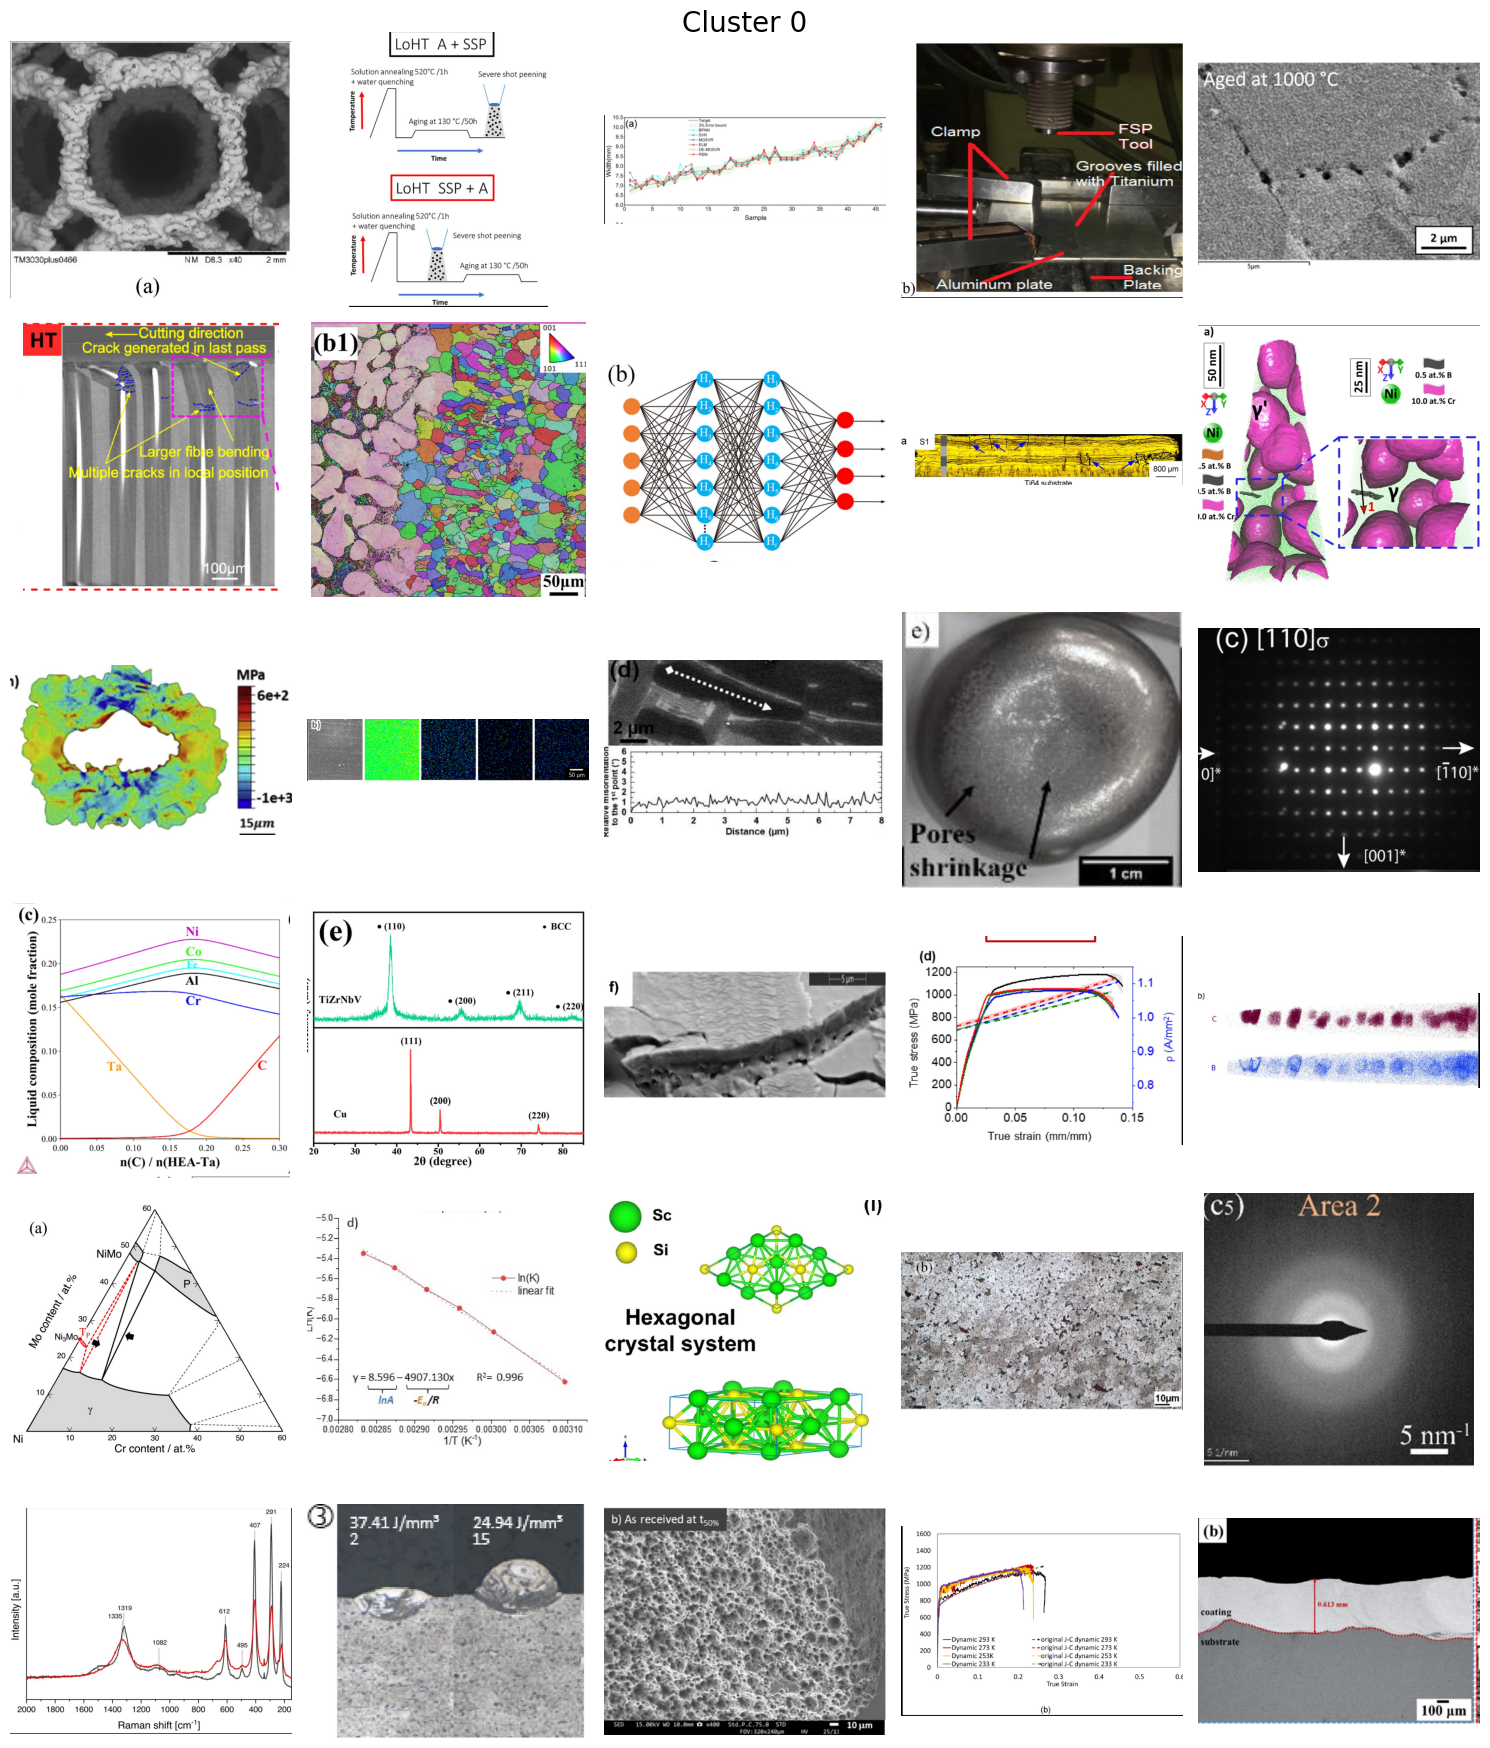


CLUSTER 1
Size: 23818


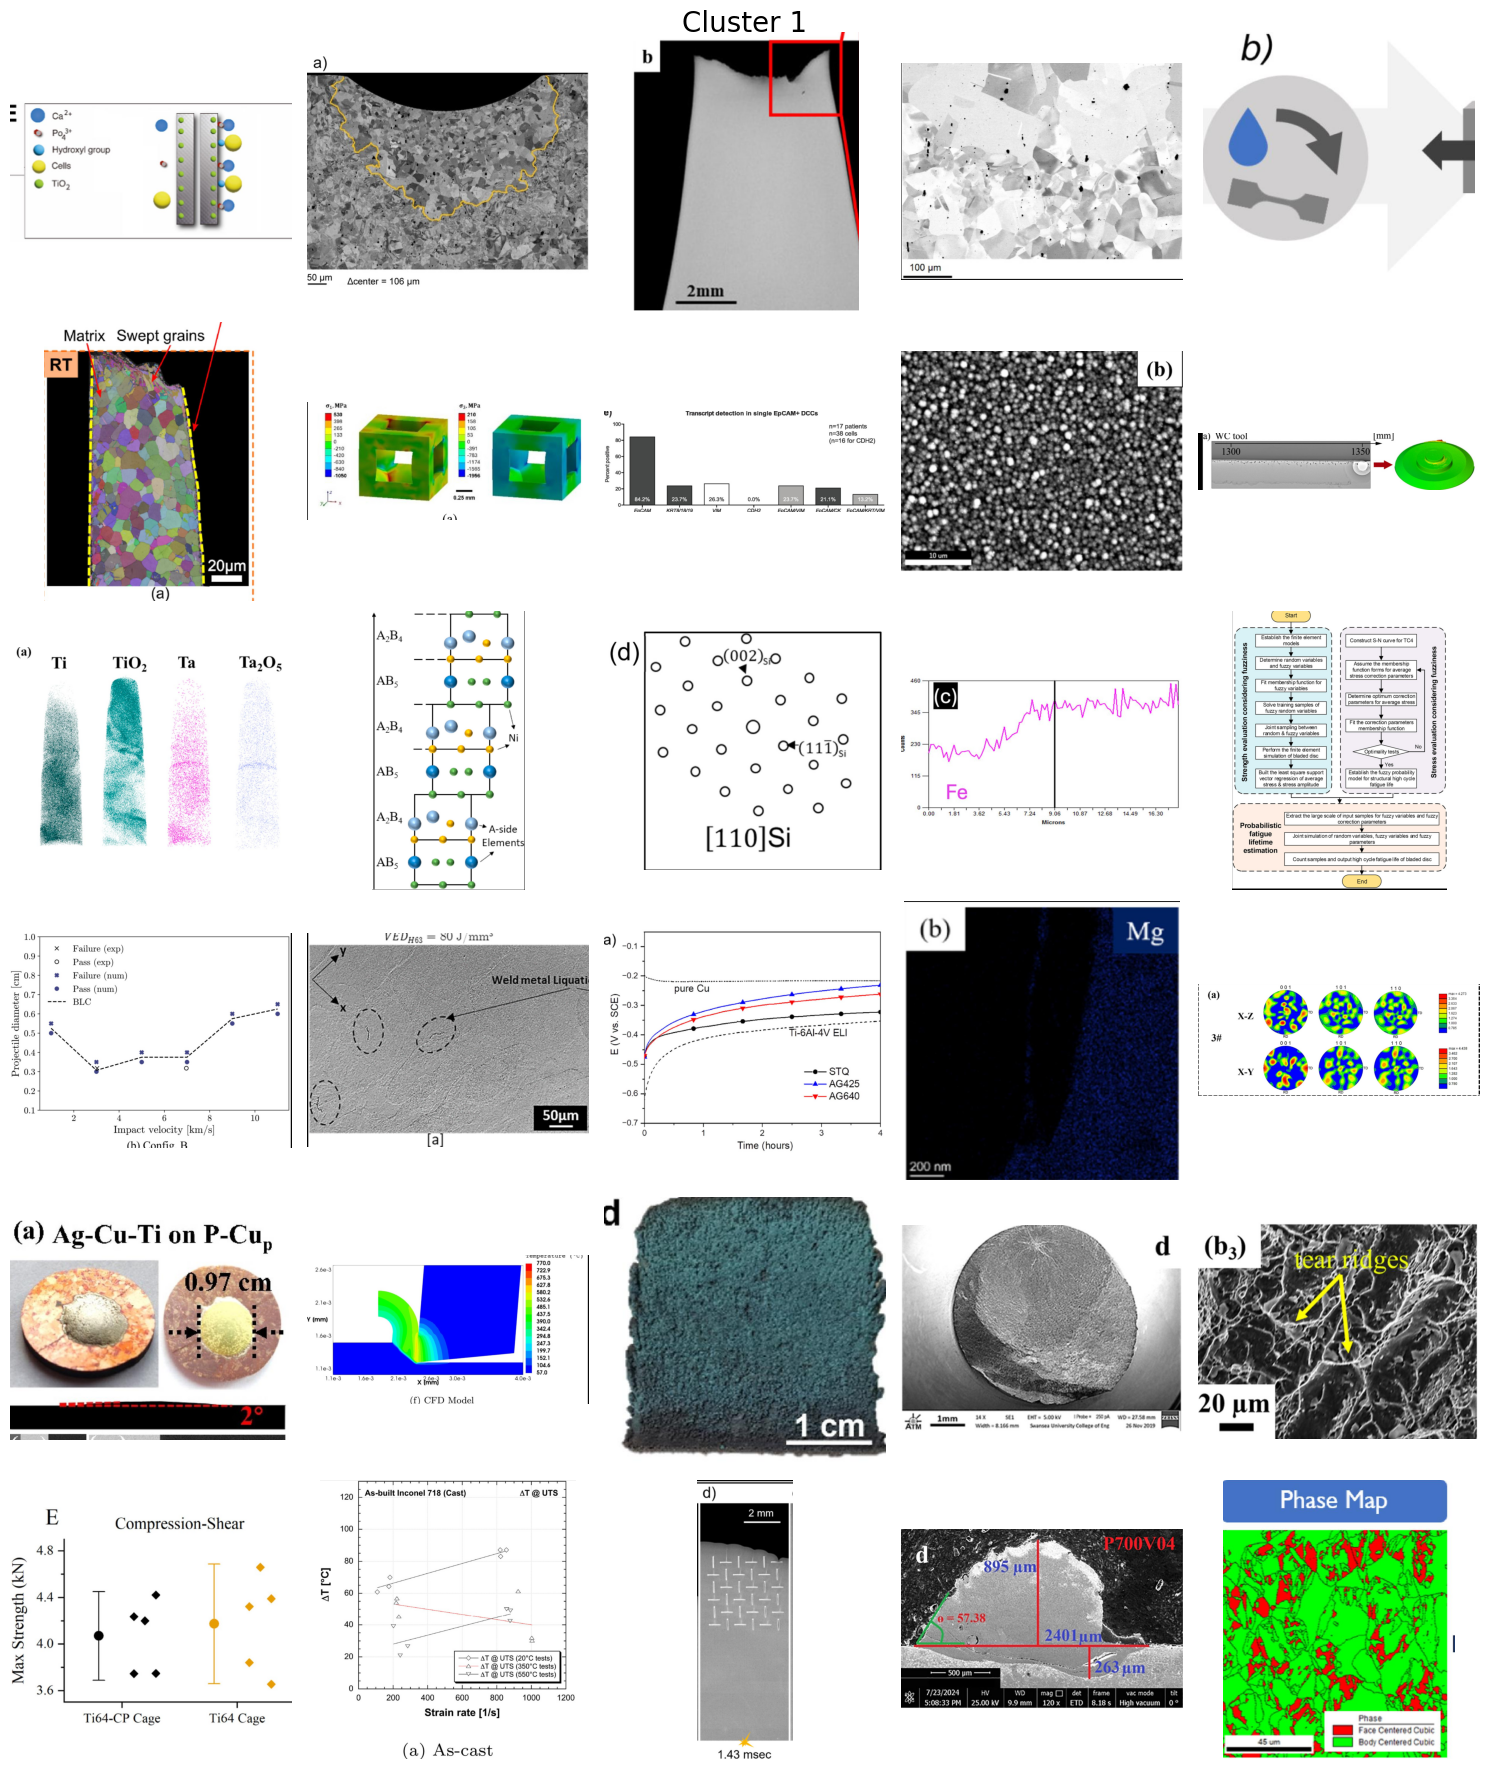


CLUSTER 2
Size: 26334


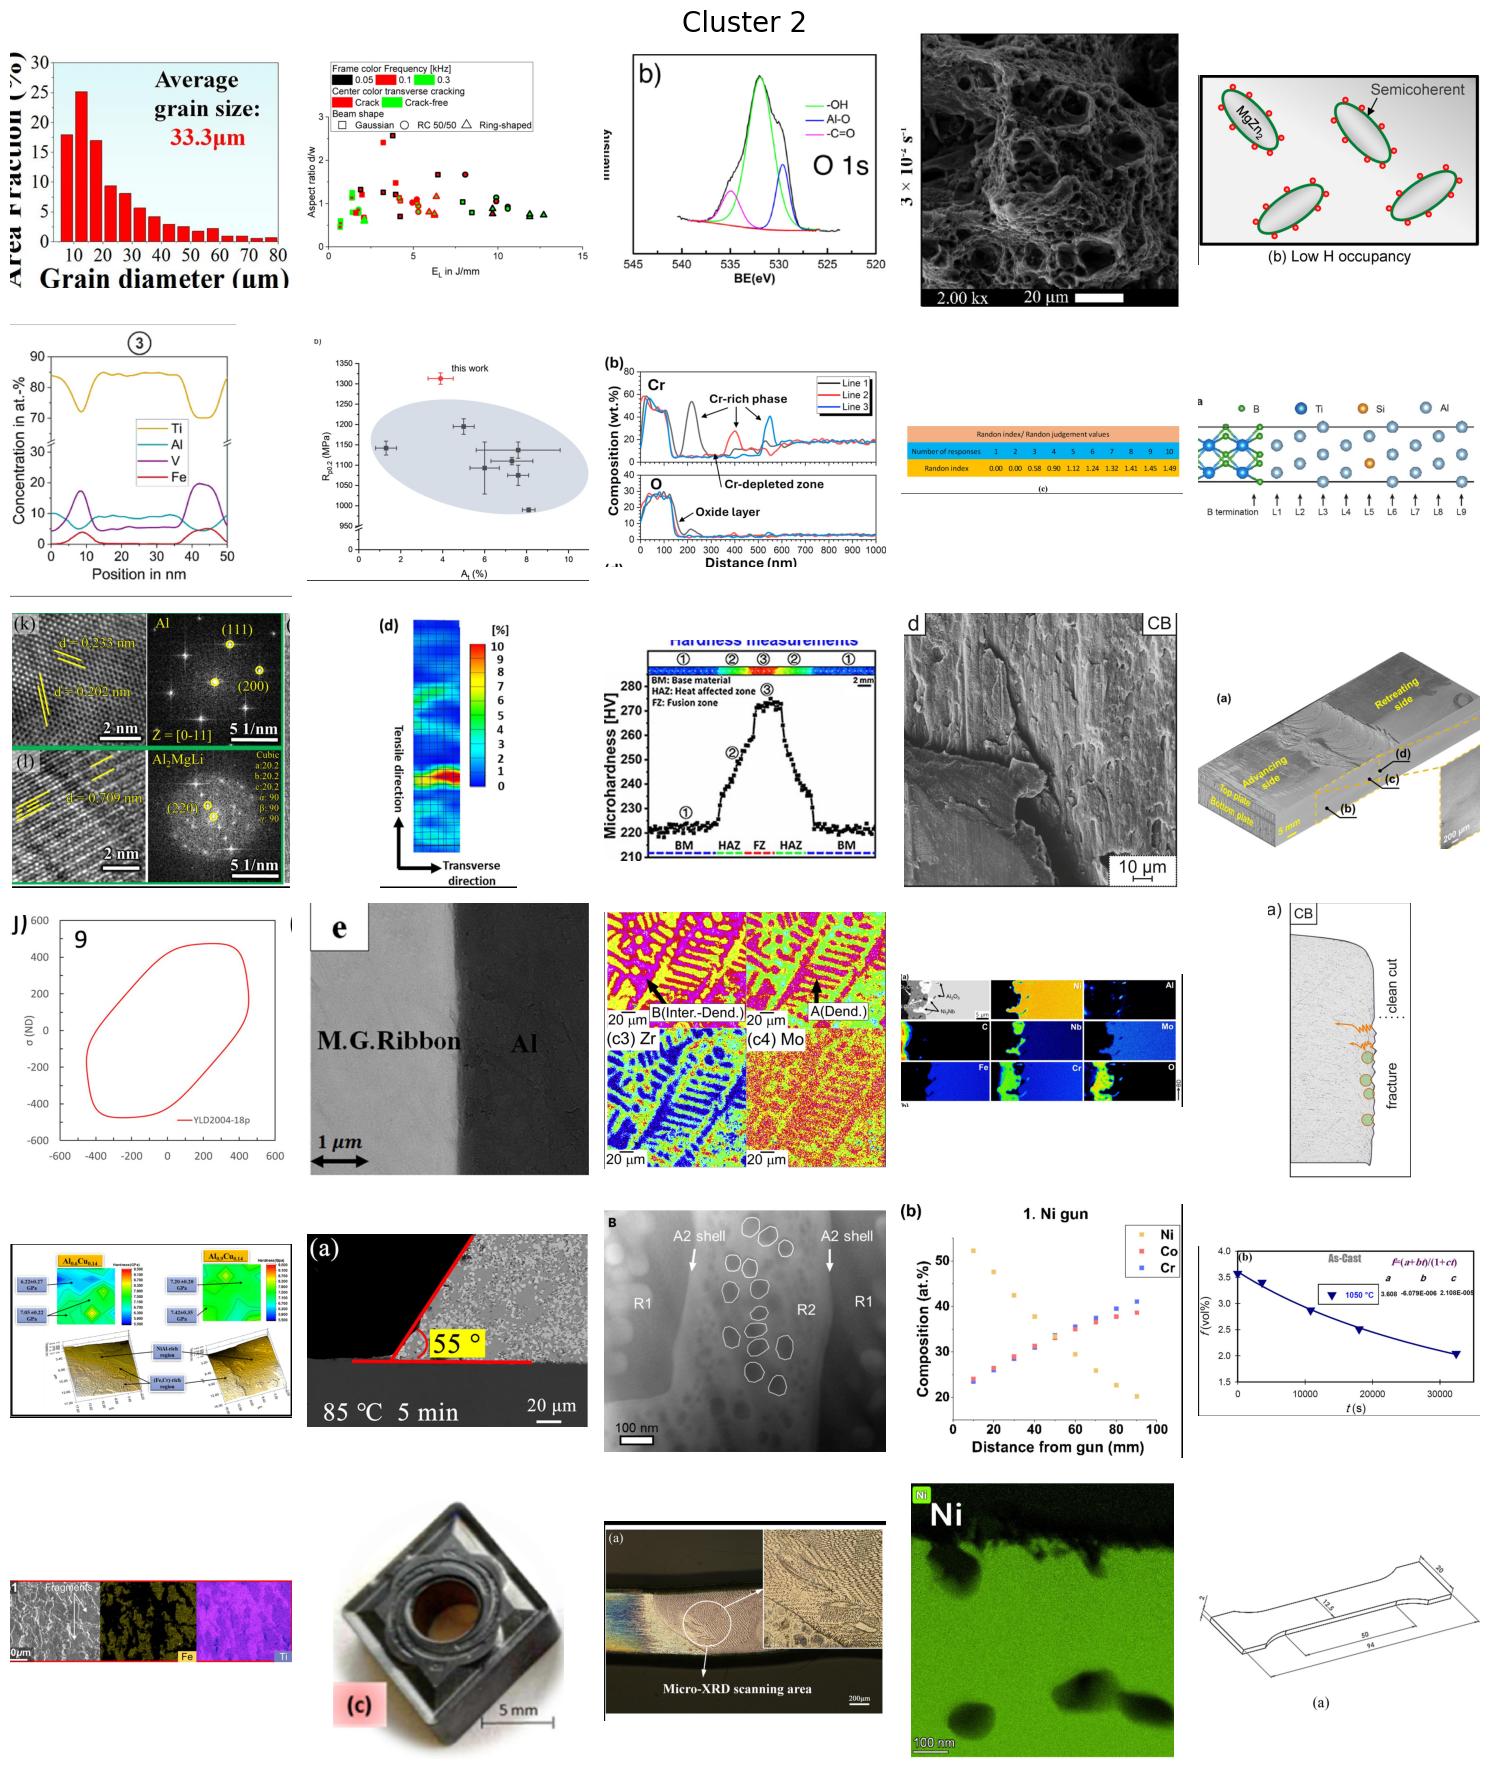

In [18]:
for c in sorted(df["cluster"].unique()):

    print(
        f"\n{'='*60}"
    )

    print(
        f"CLUSTER {c}"
    )

    print(
        f"Size: {(df['cluster']==c).sum()}"
    )

    show_cluster_random(
        c,
        n=30
    )

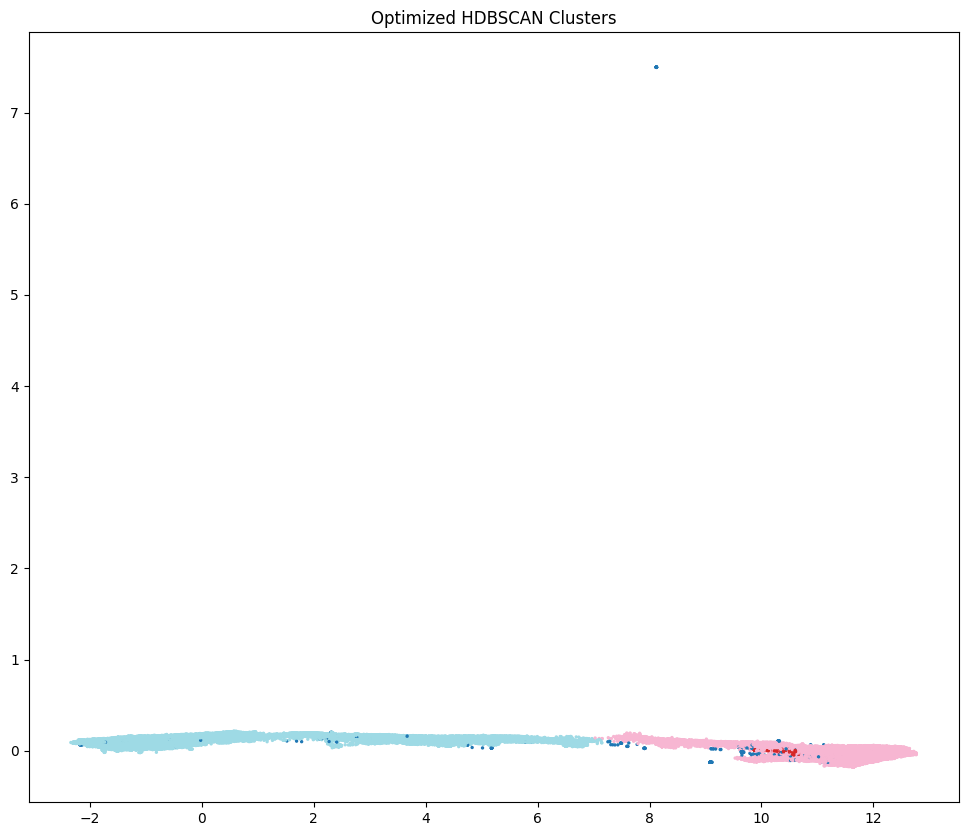

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

scatter = plt.scatter(

    umap_features[:,0],

    umap_features[:,1],

    c=labels,

    cmap="tab20",

    s=2
)

plt.title(
    "Optimized HDBSCAN Clusters"
)

plt.show()